# 02 Bond Risk Premium

**Book:** *Expected Returns* (Ilmanen)  
**Focus:** Build a local stylized 10Y bond risk premium proxy using Treasury yields and cash carry only.

## Proxy Scope And Local-Data Limits

This notebook uses only internal parquet datasets under `data/market_data/` with Treasury series from local FRED parquet files.

1. Bond return proxy uses a first-order constant-duration approximation on `DGS10` yield changes.
2. Cash proxy uses `DGS3MO` annualized yield converted to daily carry.
3. Risk-premium target is stylized excess return: bond total-return proxy minus cash carry.
4. Conditioning signals are local Treasury-only proxies: yield level (`DGS10`), slope (`T10Y2Y`), breakeven (`T10YIE`), and real-yield proxy (`DGS10 - T10YIE`).
5. No futures CTD roll, coupon curve fitting, or term-premium model is included.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
STUDY_DIR = REPO_ROOT / "workstation" / "playground" / "studies" / "2026-03-29_expected_returns_ilmanen"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(STUDY_DIR) not in sys.path:
    sys.path.insert(0, str(STUDY_DIR))

from local_parquet import (
    DEFAULT_END,
    DEFAULT_START,
    annualize_rate,
    business_days,
    forward_return,
    load_fred_series,
    read_catalog,
    rolling_zscore,
)

START = DEFAULT_START
END = DEFAULT_END
ASSUMED_DURATION_10Y = 8.5
TRADING_DAYS = 252
BRP_PANEL_CSV = STUDY_DIR / "02_bond_risk_premium_panel.csv"
BRP_SUMMARY_CSV = STUDY_DIR / "02_bond_risk_premium_regime_summary.csv"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

catalog = read_catalog()
print("Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.")
print("Study dir:", STUDY_DIR)
print("Start/End:", START, END)
print("Assumed 10Y duration:", ASSUMED_DURATION_10Y)
print("Catalog datasets:", sorted(catalog.keys()))

Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.
Study dir: /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen
Start/End: 2024-02-26 2026-02-27
Assumed 10Y duration: 8.5
Catalog datasets: ['commodities', 'equities', 'fed_liquidity', 'fx', 'ibkr_equities', 'ibkr_fx', 'macro_indicators', 'rates_yf', 'treasury_yields']


In [2]:
days = business_days(START, END)

yield_panel = load_fred_series(
    ["DGS3MO", "DGS2", "DGS10", "T10Y2Y", "T10YIE"],
    start=START,
    end=END,
).reindex(days).ffill()

yield_panel.index.name = "date"
yield_panel.tail()

series_id   DGS10  DGS2  DGS3MO  T10Y2Y  T10YIE
date                                           
2026-02-23   4.03  3.43    3.69    0.60    2.26
2026-02-24   4.03  3.43    3.69    0.61    2.26
2026-02-25   4.05  3.45    3.69    0.60    2.28
2026-02-26   4.05  3.45    3.69    0.60    2.28
2026-02-27   4.05  3.45    3.69    0.59    2.25

In [3]:
brp = yield_panel.copy()

brp["dgs10_delta_bps"] = brp["DGS10"].diff()
brp["dgs10_delta_dec"] = brp["dgs10_delta_bps"] / 100.0

# First-order duration approximation of bond price return from yield move.
brp["bond_price_ret_1d"] = -ASSUMED_DURATION_10Y * brp["dgs10_delta_dec"]
brp["bond_carry_1d"] = annualize_rate(brp["DGS10"]) / TRADING_DAYS
brp["bond_total_ret_1d"] = brp["bond_price_ret_1d"] + brp["bond_carry_1d"]

brp["cash_ret_1d"] = annualize_rate(brp["DGS3MO"]) / TRADING_DAYS
brp["brp_excess_1d"] = brp["bond_total_ret_1d"] - brp["cash_ret_1d"]

brp["bond_fwd_21d"] = (1.0 + brp["bond_total_ret_1d"].shift(-1)).rolling(21, min_periods=21).apply(np.prod, raw=True).shift(-20) - 1.0
brp["cash_fwd_21d"] = brp["cash_ret_1d"].shift(-1).rolling(21, min_periods=21).sum().shift(-20)
brp["brp_excess_fwd_21d"] = brp["bond_fwd_21d"] - brp["cash_fwd_21d"]

brp["level_10y"] = brp["DGS10"]
brp["slope_2s10s"] = brp["T10Y2Y"]
brp["breakeven_10y"] = brp["T10YIE"]
brp["real_yield_proxy"] = brp["DGS10"] - brp["T10YIE"]

brp["level_z_6m"] = rolling_zscore(brp["level_10y"], window=126)
brp["slope_z_6m"] = rolling_zscore(brp["slope_2s10s"], window=126)
brp["real_yield_z_6m"] = rolling_zscore(brp["real_yield_proxy"], window=126)

brp_model = brp[[
    "DGS3MO",
    "DGS2",
    "DGS10",
    "T10Y2Y",
    "T10YIE",
    "bond_total_ret_1d",
    "cash_ret_1d",
    "brp_excess_1d",
    "brp_excess_fwd_21d",
    "level_10y",
    "slope_2s10s",
    "breakeven_10y",
    "real_yield_proxy",
    "level_z_6m",
    "slope_z_6m",
    "real_yield_z_6m",
]].dropna()

print("Model observations:", len(brp_model))
brp_model.tail()

Model observations: 463


series_id   DGS3MO  DGS2  DGS10  T10Y2Y  T10YIE  bond_total_ret_1d  cash_ret_1d  brp_excess_1d  brp_excess_fwd_21d  level_10y  slope_2s10s  breakeven_10y  real_yield_proxy  level_z_6m  slope_z_6m  real_yield_z_6m
date                                                                                                                                                                                                                
2026-01-23    3.70  3.60   4.24    0.64    2.32           0.001868     0.000147       0.001721            0.018375       4.24         0.64           2.32              1.92    1.103846    0.914074         1.106378
2026-01-26    3.67  3.56   4.22    0.66    2.32           0.001867     0.000146       0.001722            0.016634       4.22         0.66           2.32              1.90    0.872166    1.216416         0.846781
2026-01-27    3.67  3.53   4.24    0.71    2.34          -0.001532     0.000146      -0.001677            0.016625       4.24         0.71          

## Cochrane-Piazzesi Style Forward-Rate Regression

A literal Cochrane-Piazzesi implementation is not possible here because the local parquet lake provides constant-maturity Treasury par yields rather than a fitted zero-coupon curve, and the sample window is only 2024-02-26 to 2026-02-27.

This notebook therefore uses a **CP-style approximation**:

1. Treat `DGS1`, `DGS2`, `DGS3`, `DGS5`, `DGS7`, and `DGS10` as spot-yield proxies.
2. Convert them into an approximate forward strip using log-discount interpolation.
3. Regress the **average future 21-business-day excess return** of stylized `2Y/3Y/5Y/7Y/10Y` bond proxies on those forward rates.
4. Use only information available at date $t$ to predict returns from $t+1$ onward.

This keeps the exercise honest while still testing the main CP idea: a tent-shaped combination of forward rates predicts future bond excess returns.

In [4]:
CP_PANEL_CSV = STUDY_DIR / "02_cp_forward_regression_panel.csv"
CP_WEIGHTS_CSV = STUDY_DIR / "02_cp_forward_regression_weights.csv"
CP_BUCKET_CSV = STUDY_DIR / "02_cp_forward_regression_quintiles.csv"

curve_years = {
    "DGS1": 1.0,
    "DGS2": 2.0,
    "DGS3": 3.0,
    "DGS5": 5.0,
    "DGS7": 7.0,
    "DGS10": 10.0,
}

duration_map = {
    "DGS2": 1.9,
    "DGS3": 2.8,
    "DGS5": 4.5,
    "DGS7": 6.0,
    "DGS10": 8.5,
}

cp_base = load_fred_series(
    ["DGS3MO", *curve_years.keys()],
    start=START,
    end=END,
).reindex(days).ffill()

# Approximate spot/forward rates from the local constant-maturity Treasury strip.
# This is not a zero-coupon bootstrap; it is a practical proxy using log discounting.
log_spot = np.log1p(cp_base[list(curve_years)].div(100.0))
cp_features = pd.DataFrame(index=cp_base.index)

curve_items = list(curve_years.items())
prev_col, prev_T = curve_items[0]
cp_features["spot_1y"] = cp_base[prev_col] / 100.0
for col, T in curve_items[1:]:
    fwd_log = (T * log_spot[col] - prev_T * log_spot[prev_col]) / (T - prev_T)
    cp_features[f"fwd_{int(prev_T)}y_to_{int(T)}y"] = np.expm1(fwd_log)
    prev_col, prev_T = col, T

cp_rx = pd.DataFrame(index=cp_base.index)
cash_ret_1d = annualize_rate(cp_base["DGS3MO"]) / TRADING_DAYS

for col, duration in duration_map.items():
    price_ret_1d = -duration * (cp_base[col].diff() / 100.0)
    carry_ret_1d = annualize_rate(cp_base[col]) / TRADING_DAYS
    total_ret_1d = price_ret_1d + carry_ret_1d
    bond_fwd_21d = (
        (1.0 + total_ret_1d.shift(-1))
        .rolling(21, min_periods=21)
        .apply(np.prod, raw=True)
        .shift(-20)
        - 1.0
    )
    cash_fwd_21d = cash_ret_1d.shift(-1).rolling(21, min_periods=21).sum().shift(-20)
    cp_rx[f"rx_{col.lower()}_21d"] = bond_fwd_21d - cash_fwd_21d

cp_rx["avg_rx_21d"] = cp_rx.mean(axis=1)
cp_panel = cp_features.join(cp_rx, how="inner").dropna().copy()
cp_predictors = cp_features.columns.tolist()

X = np.column_stack([np.ones(len(cp_panel)), cp_panel[cp_predictors].to_numpy()])
y = cp_panel["avg_rx_21d"].to_numpy()
beta = np.linalg.lstsq(X, y, rcond=None)[0]

cp_panel["cp_fitted_avg_rx"] = X @ beta
cp_panel["cp_score"] = cp_panel[cp_predictors].to_numpy() @ beta[1:]
cp_panel["cp_score_z_6m"] = rolling_zscore(cp_panel["cp_score"], window=126)
cp_panel["cp_quintile"] = pd.qcut(
    cp_panel["cp_score"],
    q=5,
    labels=["Q1 low", "Q2", "Q3", "Q4", "Q5 high"],
    duplicates="drop",
)

cp_weights = pd.Series(beta, index=["intercept", *cp_predictors], name="coef").to_frame()
cp_corr = cp_panel[["avg_rx_21d", "cp_fitted_avg_rx", "cp_score"]].corr().round(3)
cp_bucket_summary = (
    cp_panel.groupby("cp_quintile", observed=False)[["avg_rx_21d", "cp_fitted_avg_rx"]]
    .mean()
    .mul(100.0)
    .rename(columns={
        "avg_rx_21d": "avg_future_excess_return_pct",
        "cp_fitted_avg_rx": "fitted_future_excess_return_pct",
    })
)

brp_model = brp_model.join(
    cp_panel[["avg_rx_21d", "cp_fitted_avg_rx", "cp_score", "cp_score_z_6m"]],
    how="left",
)

print("CP-style predictors:", cp_predictors)
print("Regression observations:", len(cp_panel))
print(cp_weights.to_string())
print("\nCorrelation snapshot:")
print(cp_corr.to_string())

cp_panel.to_csv(CP_PANEL_CSV)
cp_weights.to_csv(CP_WEIGHTS_CSV)
cp_bucket_summary.to_csv(CP_BUCKET_CSV)
cp_bucket_summary

CP-style predictors: ['spot_1y', 'fwd_1y_to_2y', 'fwd_2y_to_3y', 'fwd_3y_to_5y', 'fwd_5y_to_7y', 'fwd_7y_to_10y']
Regression observations: 504
                   coef
intercept     -0.122321
spot_1y        0.400961
fwd_1y_to_2y   1.732632
fwd_2y_to_3y  -0.391208
fwd_3y_to_5y   0.130689
fwd_5y_to_7y  -4.175755
fwd_7y_to_10y  5.090124

Correlation snapshot:
                  avg_rx_21d  cp_fitted_avg_rx  cp_score
avg_rx_21d             1.000             0.558     0.558
cp_fitted_avg_rx       0.558             1.000     1.000
cp_score               0.558             1.000     1.000


             avg_future_excess_return_pct  fitted_future_excess_return_pct
cp_quintile                                                               
Q1 low                          -0.661473                        -0.772720
Q2                              -0.287806                        -0.237013
Q3                              -0.077073                         0.067082
Q4                               0.472485                         0.410564
Q5 high                          0.753958                         0.733605

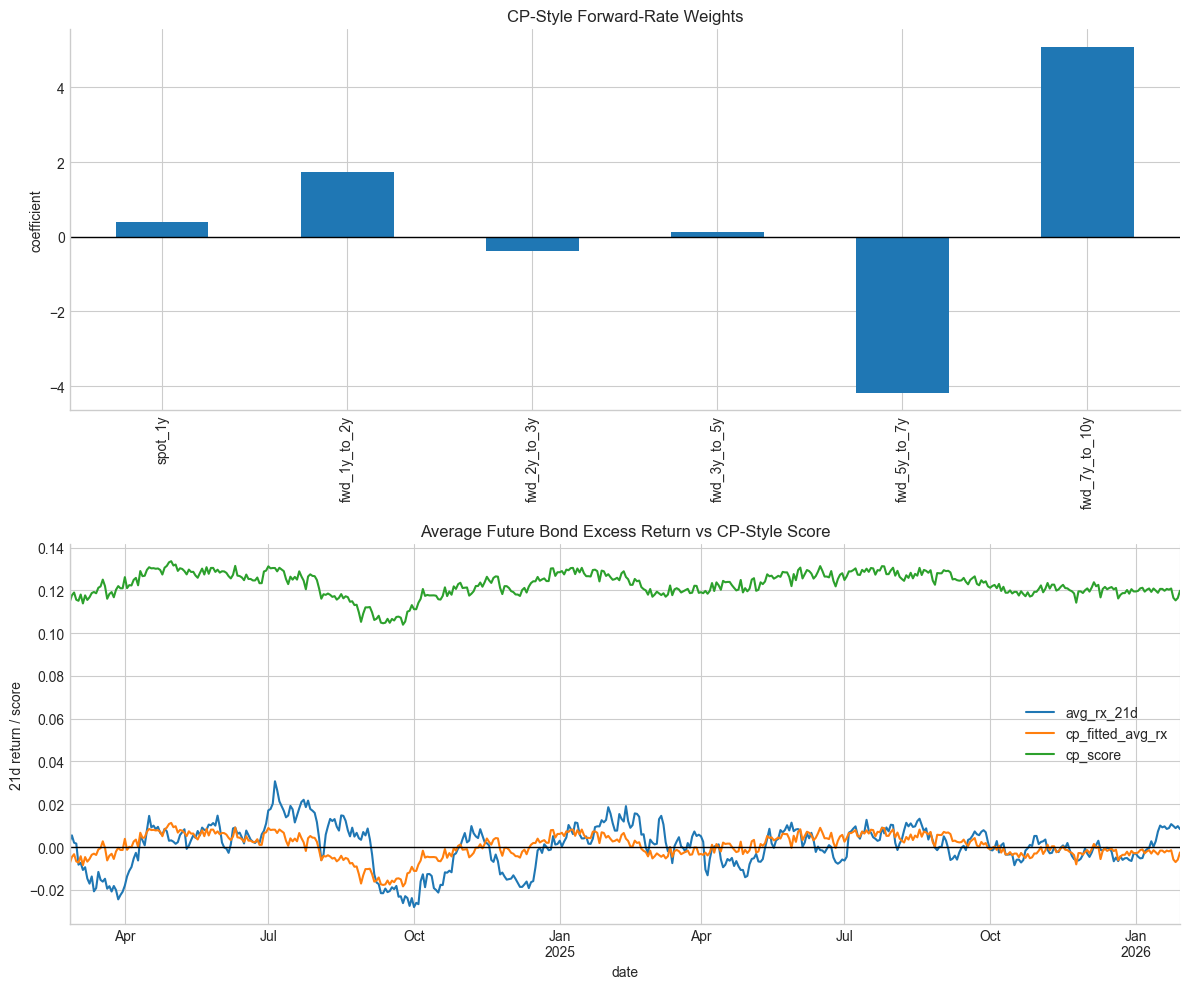

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

cp_weights.drop(index="intercept")["coef"].plot(
    kind="bar",
    ax=axes[0],
    color="tab:blue",
    title="CP-Style Forward-Rate Weights",
)
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_ylabel("coefficient")

cp_panel[["avg_rx_21d", "cp_fitted_avg_rx", "cp_score"]].plot(
    ax=axes[1],
    title="Average Future Bond Excess Return vs CP-Style Score",
)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_ylabel("21d return / score")

plt.tight_layout()
plt.show()


In [6]:
predictors = ["level_10y", "slope_2s10s", "breakeven_10y", "real_yield_proxy"]

corr_table = brp_model[predictors + ["brp_excess_1d", "brp_excess_fwd_21d"]].corr().round(3)

brp_model["slope_regime"] = pd.qcut(brp_model["slope_2s10s"], q=4, labels=["Q1 flat/inv", "Q2", "Q3", "Q4 steep"])
brp_model["real_yield_regime"] = pd.qcut(brp_model["real_yield_proxy"], q=4, labels=["Q1 low", "Q2", "Q3", "Q4 high"])

regime_summary = pd.concat([
    brp_model.groupby("slope_regime", observed=False)["brp_excess_fwd_21d"].mean().rename("fwd21_excess_by_slope"),
    brp_model.groupby("real_yield_regime", observed=False)["brp_excess_fwd_21d"].mean().rename("fwd21_excess_by_real_yield"),
], axis=1)

print("Contemporaneous/Predictive Correlation Snapshot")
print(corr_table.loc[predictors, ["brp_excess_1d", "brp_excess_fwd_21d"]].to_string())
regime_summary

Contemporaneous/Predictive Correlation Snapshot
                  brp_excess_1d  brp_excess_fwd_21d
level_10y                -0.096               0.485
slope_2s10s              -0.051              -0.120
breakeven_10y            -0.050               0.425
real_yield_proxy         -0.101               0.424


             fwd21_excess_by_slope  fwd21_excess_by_real_yield
Q1 flat/inv               0.006198                         NaN
Q2                       -0.006676                    0.001811
Q3                        0.004128                    0.002732
Q4 steep                  0.001059                         NaN
Q1 low                         NaN                   -0.008478
Q4 high                        NaN                    0.009253

saved panel to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen/02_bond_risk_premium_panel.csv
saved regime summary to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen/02_bond_risk_premium_regime_summary.csv


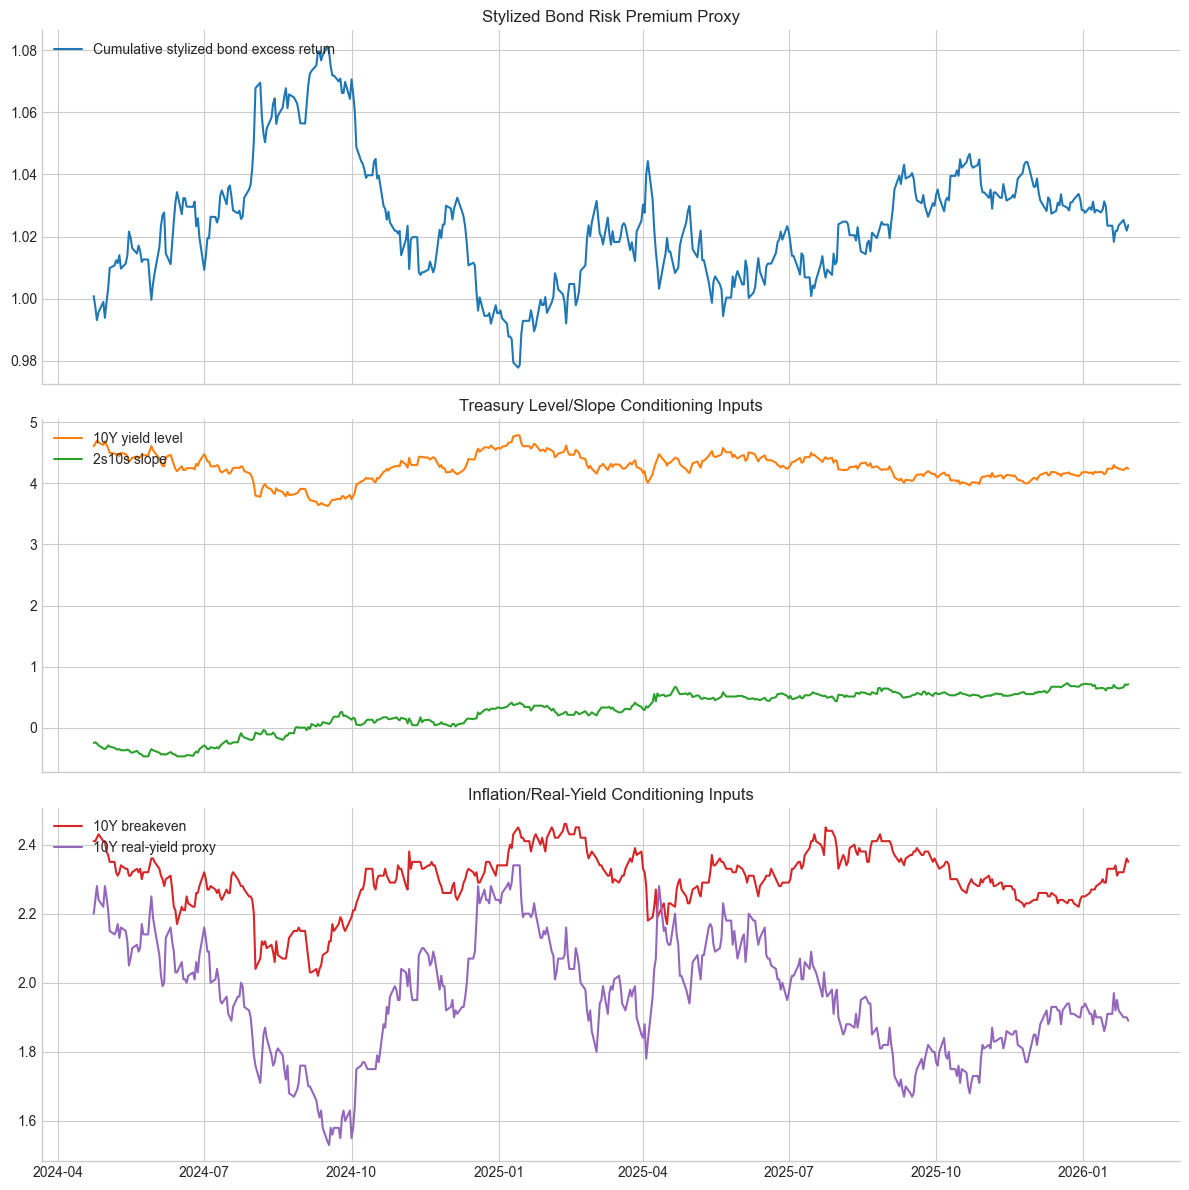

            bond_total_ret_1d  cash_ret_1d  brp_excess_1d  brp_excess_fwd_21d
date                                                                         
2026-01-23           0.001868     0.000147       0.001721            0.018375
2026-01-26           0.001867     0.000146       0.001722            0.016634
2026-01-27          -0.001532     0.000146      -0.001677            0.016625
2026-01-28          -0.001531     0.000146      -0.001677            0.018352
2026-01-29           0.001868     0.000146       0.001723            0.016611

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

cum_brp = (1.0 + brp_model["brp_excess_1d"]).cumprod()
axes[0].plot(cum_brp.index, cum_brp.values, color="tab:blue", label="Cumulative stylized bond excess return")
axes[0].set_title("Stylized Bond Risk Premium Proxy")
axes[0].legend(loc="upper left")

axes[1].plot(brp_model.index, brp_model["level_10y"], color="tab:orange", label="10Y yield level")
axes[1].plot(brp_model.index, brp_model["slope_2s10s"], color="tab:green", label="2s10s slope")
axes[1].set_title("Treasury Level/Slope Conditioning Inputs")
axes[1].legend(loc="upper left")

axes[2].plot(brp_model.index, brp_model["breakeven_10y"], color="tab:red", label="10Y breakeven")
axes[2].plot(brp_model.index, brp_model["real_yield_proxy"], color="tab:purple", label="10Y real-yield proxy")
axes[2].set_title("Inflation/Real-Yield Conditioning Inputs")
axes[2].legend(loc="upper left")

plt.tight_layout()
plt.show()

brp_model.to_csv(BRP_PANEL_CSV)
regime_summary.to_csv(BRP_SUMMARY_CSV)
print("saved panel to", BRP_PANEL_CSV)
print("saved regime summary to", BRP_SUMMARY_CSV)
brp_model[["bond_total_ret_1d", "cash_ret_1d", "brp_excess_1d", "brp_excess_fwd_21d"]].tail()